### Construct Manifest

The whole point of this file is to align the experimental data with the calculated data, and do a little analysis on the calculation results (from AM1 and R2scan-3C).

The workflow is like smiles > .xyz files > .gjf or .inp files > results > write to .csv

We need to check that the .csv file is aligned with the smiles we started with; we do this by comparing the filenames we wrote out and the output file names, basically.

There is also a few tools for checkign the quality of the data from AM1 / R2SCAN-3C and for producing some of the plots in the paper.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde


In [2]:
# the csv files are just the output of the calculations etc. They are unaltered from the HPC.
# RJM reminder - need to put those on github too. 
df_manifest = pd.read_csv("..//results//de_cp_manifest.csv")
df_am1      = pd.read_csv("..//results//maier_meier_batch_am1.csv")
df_orca     = pd.read_csv("..//results//orca_mm_batch.csv")

# first get them all lined up according to the id used for the HPC jobs (something like de_cp_xxxx)
df_manifest["id"] = df_manifest["id"].astype(str)

df_am1["id"] = df_am1["filename"].astype(str).str.replace(".log", "", regex=False)
df_orca["id"] = df_orca["filename"].astype(str).str.replace(".property.txt", "", regex=False)

# inevitably we have duplicates so just bin them
dup_am1 = df_am1[df_am1.duplicated("id", keep=False)].sort_values("id")
dup_orc = df_orca[df_orca.duplicated("id", keep=False)].sort_values("id")

print(f"AM1 duplicates:  {dup_am1['id'].nunique()} ids, {len(dup_am1)} rows")
print(f"ORCA duplicates: {dup_orc['id'].nunique()} ids, {len(dup_orc)} rows")

# print out some duplicates.
print("\nExample AM1 duplicate ids:", dup_am1["id"].value_counts().head(10))
print("\nExample ORCA duplicate ids:", dup_orc["id"].value_counts().head(10))



def choose_best_row(df, ok_col=None):
    """
    This function consolidates to just one row per id.
    Priority:
      1) ok_col True (if provided and exists)
      2) otherwise keep the last occurrence (often the rerun/final appended row)
    """
    d = df.copy()

    if ok_col is not None and ok_col in d.columns:
        # sort so "best" is last within each id, then drop duplicates keeping last
        # (True > False, so True rows come last)
        d[ok_col] = d[ok_col].astype(str).str.upper().isin(["TRUE", "T", "1", "YES"])
        d = d.sort_values(["id", ok_col])
        d = d.drop_duplicates("id", keep="last")
    else:
        d = d.drop_duplicates("id", keep="last")

    return d


# if AM1 has "normal_termination" we keep it:
df_am1_u = choose_best_row(df_am1, ok_col="normal_termination")

# if ORCA file has'status' == "ok" we keep it 
if "status" in df_orca.columns:
    df_orca2 = df_orca.copy()
    df_orca2["ok_flag"] = df_orca2["status"].astype(str).str.lower().eq("ok")
    df_orca_u = choose_best_row(df_orca2, ok_col="ok_flag")
else:
    df_orca_u = choose_best_row(df_orca, ok_col=None)

# select teh columns and merge them
df_manifest_sel = df_manifest[["id", "smiles", "delta_eps"]].copy()

df_am1_sel = df_am1_u[["id", "delta_eps"]].rename(columns={"delta_eps": "delta_eps_am1"})
df_orca_sel = df_orca_u[["id", "delta_eps"]].rename(columns={"delta_eps": "delta_eps_r2scan3c"})

# Validate uniqueness now
assert df_am1_sel["id"].is_unique, "AM1 still has duplicate ids after dedupe"
assert df_orca_sel["id"].is_unique, "ORCA still has duplicate ids after dedupe"
assert df_manifest_sel["id"].is_unique, "Manifest has duplicate ids (shouldn't)"

df_master = df_manifest_sel.merge(df_am1_sel, on="id", how="left", validate="one_to_one")
df_master = df_master.merge(df_orca_sel, on="id", how="left", validate="one_to_one")

# print some info and save the mater csv file we'll use for later analsis...
print("\nCounts in master table:")
print("Total molecules:", len(df_master))
print("Experimental Δε:", df_master["delta_eps"].notna().sum())
print("AM1 Δε:", df_master["delta_eps_am1"].notna().sum())
print("r2SCAN-3c Δε:", df_master["delta_eps_r2scan3c"].notna().sum())

out_file = "de_cp_master_delta_eps.csv"
df_master.to_csv(out_file, index=False)
print(f"\nWrote: {out_file}")


AM1 duplicates:  1 ids, 158 rows
ORCA duplicates: 1 ids, 125 rows

Example AM1 duplicate ids: id
nan    158
Name: count, dtype: int64

Example ORCA duplicate ids: id
nan    125
Name: count, dtype: int64

Counts in master table:
Total molecules: 3235
Experimental Δε: 3087
AM1 Δε: 2997
r2SCAN-3c Δε: 3084

Wrote: de_cp_master_delta_eps.csv


AM1:       N=2849  RMSE=9.66  R²=0.632  +→−=3.0  −→+=10.0
r2SCAN-3c: N=2930   RMSE=11.20  R²=0.500  +→−=3.0  −→+=13.0


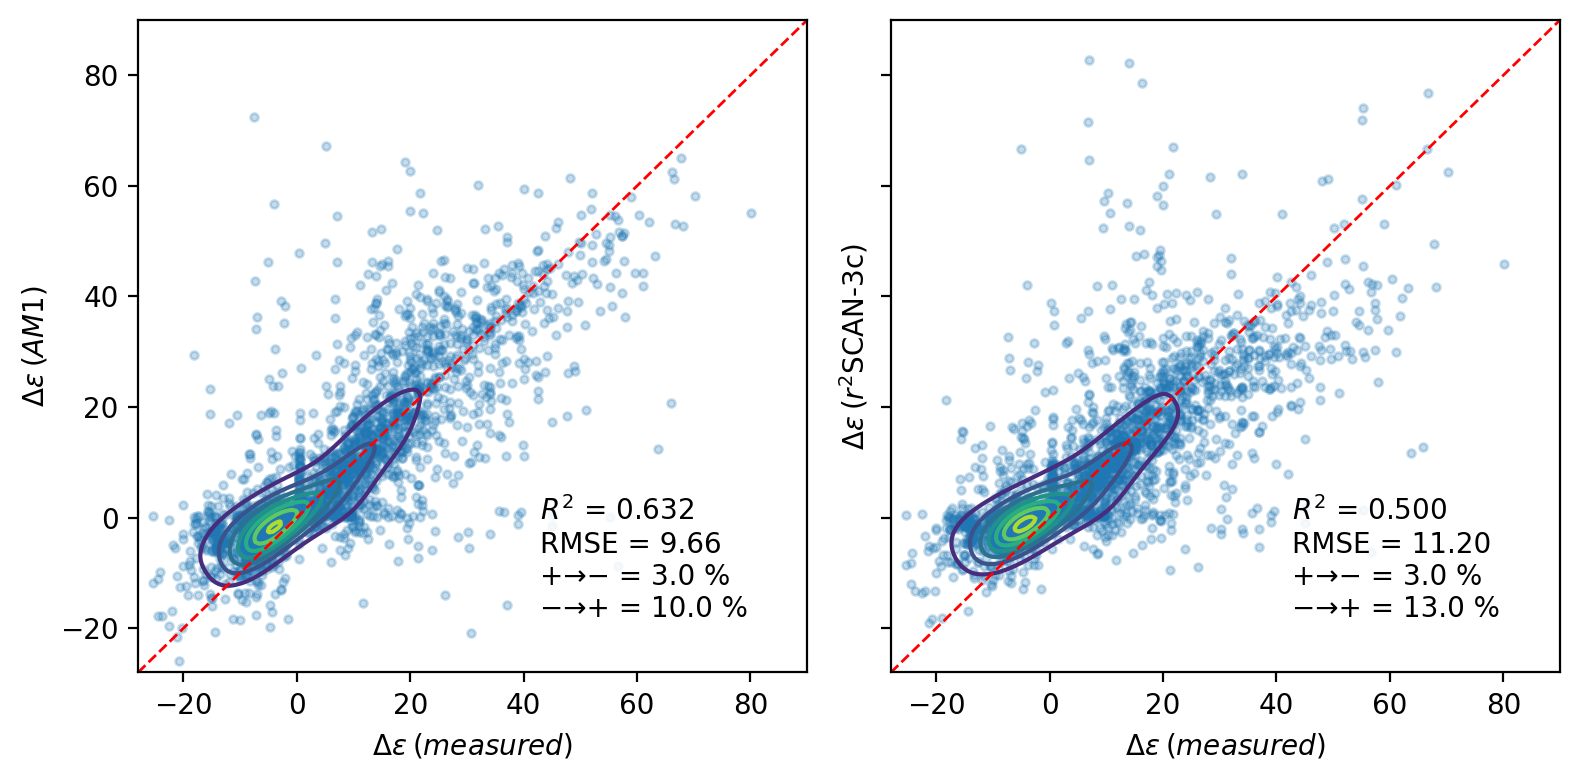

In [9]:
df = pd.read_csv("de_cp_master_delta_eps.csv")

# make the columns numeric, I am fairly sure the experimental data (delta_eps) has the odd thing with a comma in it.
num_cols = ["delta_eps", "delta_eps_am1", "delta_eps_r2scan3c"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

def sign_error_breakdown(x, y, drop_zero=True):
    '''
    This is our check of do the experiment and calcualtion give the same sign
    it returns a PERCENTAGE. No point comparing actuals when there are different
    numbers of datapoints (becasue some calculations fail)
    '''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if drop_zero:
        m = (x != 0) & (y != 0)
        x, y = x[m], y[m]
    pos_to_neg = np.round((np.sum((x > 0) & (y < 0)) / len(x))*100,0)
    neg_to_pos = np.round((np.sum((x < 0) & (y > 0)) / len(x))*100,0)
    return pos_to_neg, neg_to_pos, len(x)


def metrics(x, y):
    '''
    standard metrics, rmse, r2, sign breakdown (p2n, np2, n).
    '''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    rmse = np.sqrt(mean_squared_error(x, y))
    r2 = r2_score(x, y)
    p2n, n2p, n = sign_error_breakdown(x, y)
    return rmse, r2, p2n, n2p, n

def density_panel(ax, x, y, xlabel, ylabel, lims,
                  ngrid=200, n_contours=7, scatter_n=6000):
    '''
    This is part of the plotting we'll do later; scatter plot of pred vs actuals and 
    use contours for the kernel density estimate so we can still see the dense data.
    '''
    rmse, r2, p2n, n2p, n = metrics(x, y)

    minima, maxima = lims
    xi = np.linspace(minima, maxima, ngrid)
    yi = np.linspace(minima, maxima, ngrid)
    Xg, Yg = np.meshgrid(xi, yi)

    kde = gaussian_kde(np.vstack([x, y]))
    Zg = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

    ax.contour(Xg, Yg, Zg, levels=n_contours)

    # might need to subsample 
    if len(x) > scatter_n:
        idx = np.random.choice(len(x), size=scatter_n, replace=False)
        xs, ys = x[idx], y[idx]
    else:
        xs, ys = x, y
    ax.scatter(xs, ys, s=8, alpha=0.25)

    ax.plot([minima, maxima], [minima, maxima], "r--", linewidth=1)

    ax.set_xlim(minima, maxima)
    ax.set_ylim(minima, maxima)
    #ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.text(
        0.6, 0.27, # empirically picked positions so we can tag on (a) / (b) labels later on
        f"$R^2$ = {r2:.3f}\n"
        f"RMSE = {rmse:.2f}\n"
        f"+→− = {p2n} %\n"
        f"−→+ = {n2p} %",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, linewidth=0)
    )

    return rmse, r2


# first up, use the am1 data
df_am1 = df.dropna(subset=["delta_eps", "delta_eps_am1"])
x_am1 = df_am1["delta_eps"].to_numpy(dtype=float)
y_am1 = df_am1["delta_eps_am1"].to_numpy(dtype=float)
rmse_am1, r2_am1, p2n_am1, n2p_am1, n_am1 = metrics(x_am1, y_am1)

# same but r2scan-3c
df_r2 = df.dropna(subset=["delta_eps", "delta_eps_r2scan3c"])
x_r2 = df_r2["delta_eps"].to_numpy(dtype=float)
y_r2 = df_r2["delta_eps_r2scan3c"].to_numpy(dtype=float)
rmse_r2, r2_r2, p2n_r2, n2p_r2, n_r2 = metrics(x_r2, y_r2)

print(f"AM1:       N={n_am1}  RMSE={rmse_am1:.2f}  R²={r2_am1:.3f}  +→−={p2n_am1}  −→+={n2p_am1}")
print(f"r2SCAN-3c: N={n_r2}   RMSE={rmse_r2:.2f}  R²={r2_r2:.3f}  +→−={p2n_r2}  −→+={n2p_r2}")

# share axis limits so it looks nice
all_vals = np.concatenate([x_am1, y_am1, x_r2, y_r2])
lims = (-28, 90) # picked based on experimental data and visuals.

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=200, sharex=True, sharey=True)

density_panel(
    axes[0], x_am1, y_am1,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"$\Delta\epsilon\:(AM1)$",
    lims=lims
)

density_panel(
    axes[1], x_r2, y_r2,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"$\Delta\epsilon\:(r^2$SCAN-3c$)$",
    lims=lims
)

plt.tight_layout()
plt.show()


In [5]:
# σ(Δε) for the same subsets used in each comparison
sigma_am1 = df_am1["delta_eps"].std(ddof=0)
sigma_r2  = df_r2["delta_eps"].std(ddof=0)

print(f"AM1 subset:      σ(Δε) = {sigma_am1:.2f}   RMSE/σ = {rmse_am1/sigma_am1:.2f}")
print(f"r2SCAN-3c subset: σ(Δε) = {sigma_r2:.2f}   RMSE/σ = {rmse_r2/sigma_r2:.2f}")


AM1 subset:      σ(Δε) = 15.92   RMSE/σ = 0.61
r2SCAN-3c subset: σ(Δε) = 15.84   RMSE/σ = 0.71


AM1:       N=2849  RMSE=9.66  R²=0.632  +→−=3.0  −→+=10.0
r2SCAN-3c: N=2930   RMSE=11.20  R²=0.500  +→−=3.0  −→+=13.0


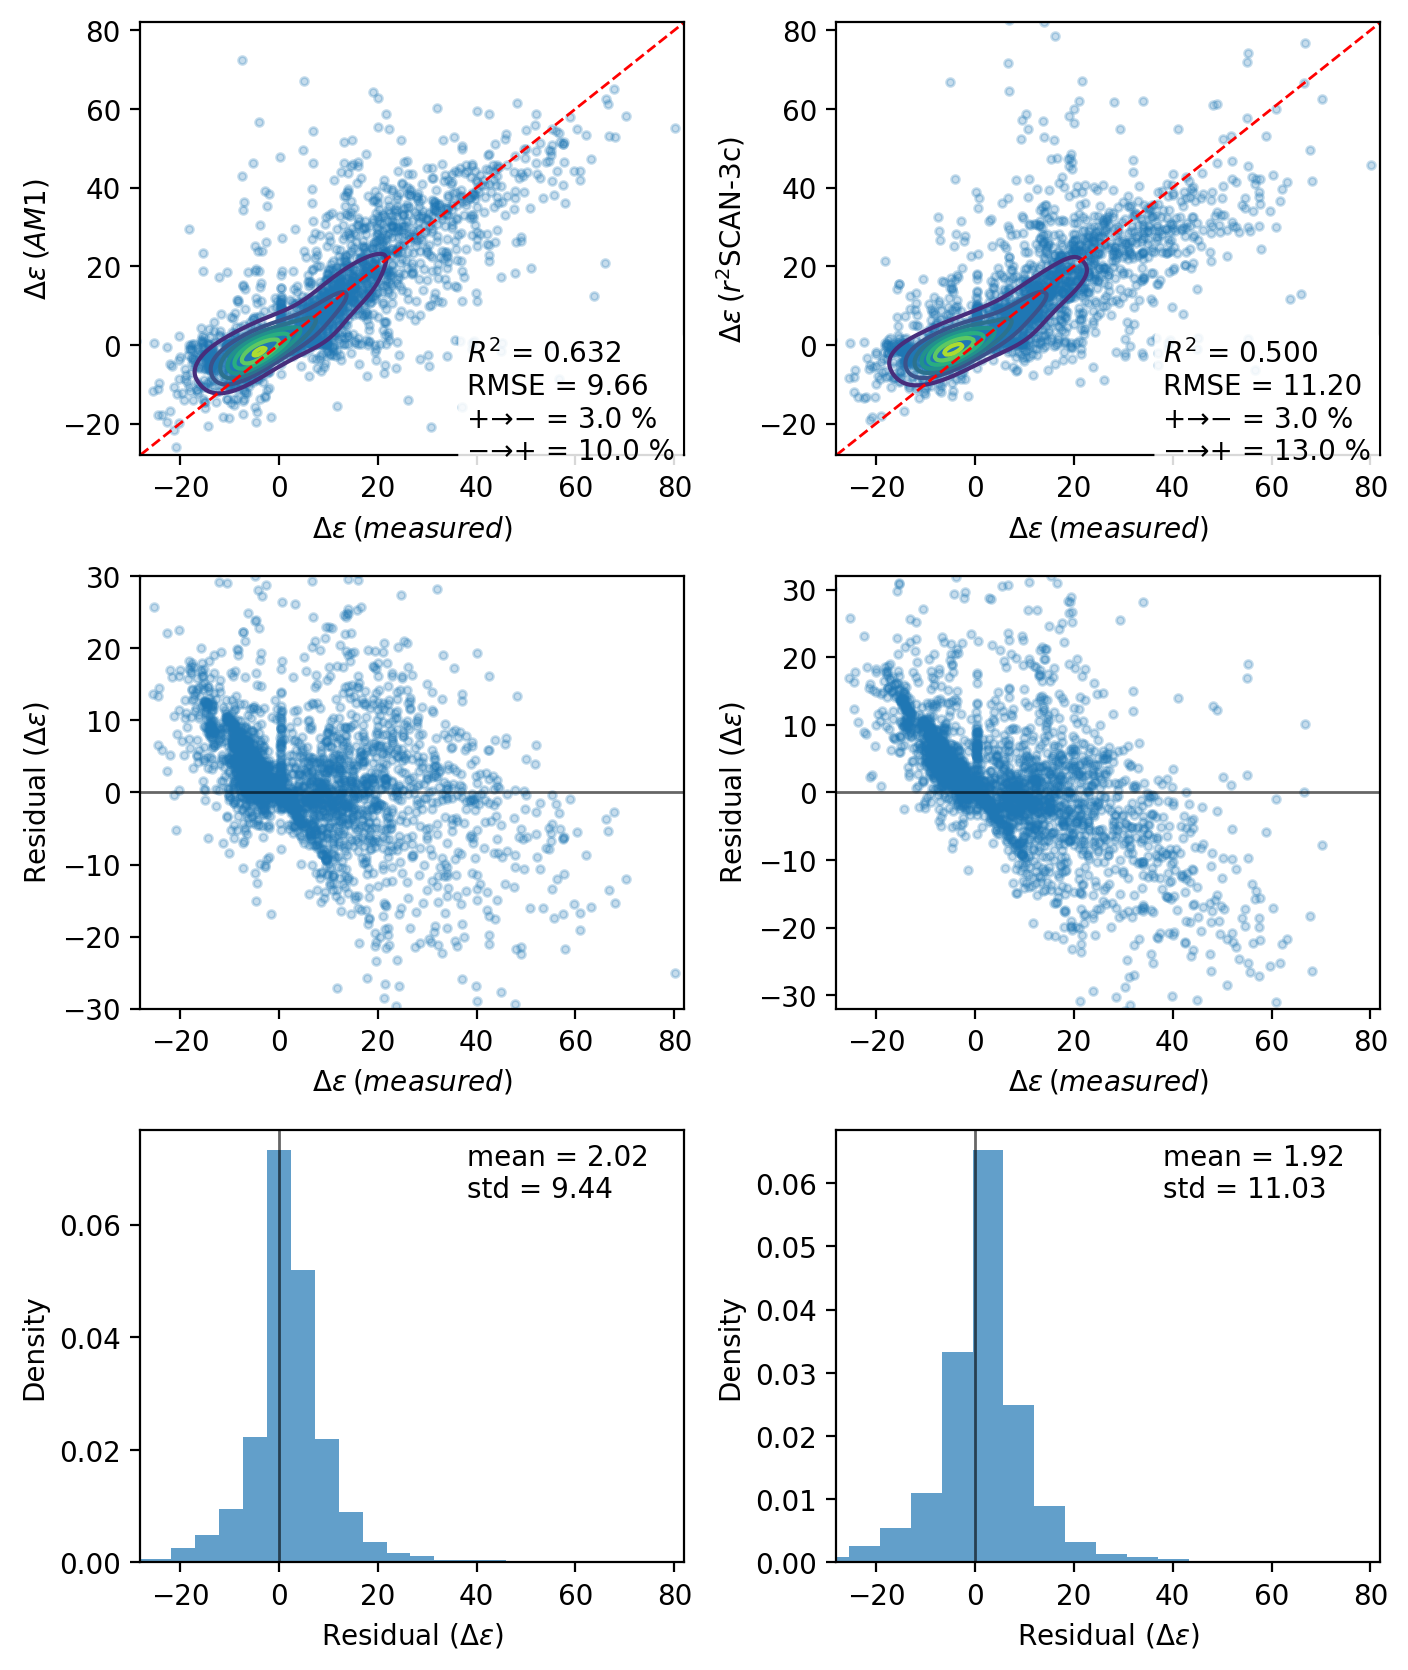

In [10]:
def residuals_panel(ax, x, y, xlabel, ylabel, xlims, scatter_n=6000):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    res = y - x

    # subsample for clarity
    if len(x) > scatter_n:
        idx = np.random.choice(len(x), size=scatter_n, replace=False)
        xs, rs = x[idx], res[idx]
    else:
        xs, rs = x, res

    rclean = res[np.isfinite(res)]
    if rclean.size:
        q = np.nanquantile(np.abs(rclean), 0.98)
        rlim = max(5.0, float(np.ceil(q)))
    else:
        rlim = 5.0

    ax.axhline(0, color="k", lw=1, alpha=0.6)
    ax.scatter(xs, rs, s=8, alpha=0.25)

    ax.set_xlim(*xlims)
    ax.set_ylim(-rlim, rlim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    return res


def residual_hist_panel(ax, res, xlabel, ylabel="Density", bins=30, lims=[-20,80]):
    res = np.asarray(res, dtype=float)
    res = res[np.isfinite(res)]

    ax.hist(res, bins=bins, density=True, alpha=0.7)
    ax.axvline(0, color="k", lw=1, alpha=0.6)

    mu = np.nanmean(res) if res.size else np.nan
    sig = np.nanstd(res) if res.size else np.nan

    ax.text(
        0.6, 0.97,
        f"mean = {mu:.2f}\nstd = {sig:.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, linewidth=0)
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(lims)


# ----- AM1 -----
df_am1 = df.dropna(subset=["delta_eps", "delta_eps_am1"])
x_am1 = df_am1["delta_eps"].to_numpy(dtype=float)
y_am1 = df_am1["delta_eps_am1"].to_numpy(dtype=float)
rmse_am1, r2_am1, p2n_am1, n2p_am1, n_am1 = metrics(x_am1, y_am1)

# ----- r2SCAN-3c -----
df_r2 = df.dropna(subset=["delta_eps", "delta_eps_r2scan3c"])
x_r2 = df_r2["delta_eps"].to_numpy(dtype=float)
y_r2 = df_r2["delta_eps_r2scan3c"].to_numpy(dtype=float)
rmse_r2, r2_r2, p2n_r2, n2p_r2, n_r2 = metrics(x_r2, y_r2)

print(f"AM1:       N={n_am1}  RMSE={rmse_am1:.2f}  R²={r2_am1:.3f}  +→−={p2n_am1}  −→+={n2p_am1}")
print(f"r2SCAN-3c: N={n_r2}   RMSE={rmse_r2:.2f}  R²={r2_r2:.3f}  +→−={p2n_r2}  −→+={n2p_r2}")

# ----- shared axis limits -----
lims = (-28, 82)

# ---------------------------
# 3 rows x 2 columns (ALL PANELS SAME SIZE)
# Col 0 = AM1, Col 1 = r2SCAN-3c
# Row 0 = parity, Row 1 = residuals, Row 2 = histogram
# ---------------------------
fig, axes = plt.subplots(
    3, 2,
    figsize=(8, 10),
    dpi=200,
    gridspec_kw=dict(height_ratios=[1, 1, 1], wspace=0.28, hspace=0.28)
)

# Row 1: parity
density_panel(
    axes[0, 0], x_am1, y_am1,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"$\Delta\epsilon\:(AM1)$",
    lims=lims
)
density_panel(
    axes[0, 1], x_r2, y_r2,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"$\Delta\epsilon\:(r^2$SCAN-3c$)$",
    lims=lims
)

# Row 2: residuals vs measured
res_am1 = residuals_panel(
    axes[1, 0], x_am1, y_am1,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"Residual ($\Delta\epsilon$)",
    xlims=lims
)
res_r2 = residuals_panel(
    axes[1, 1], x_r2, y_r2,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"Residual ($\Delta\epsilon$)",
    xlims=lims
)

# Row 3: residual hist
residual_hist_panel(
    axes[2, 0], res_am1,
    xlabel=r"Residual ($\Delta\epsilon$)",
    lims = lims,
)
residual_hist_panel(
    axes[2, 1], res_r2,
    xlabel=r"Residual ($\Delta\epsilon$)",
    lims = lims,
)

plt.show()
